## Machine Learning for Space Applications
# Lab 2: Unsupervised data exploration

1.   Google Satellite Embeddings
2.   CORINE 2018


# Objectives:

1. Construct a large, distributed, balanced GEF/CORINE dataset

    a. Tile the AOI using H3 Hex zoom-level-4 tiles

    b. For each H3z4 cell, tile using H3 Hex zoom-level-6 tiles

    c. Filter and aggregate samples using CORINE dataset

2. UMAP on the entire dataset
3. Apply three different outlier detection method to two different classes
4. Select the best outlier detection method and apply to all classes
5. Visualise and document the results

Authors: 
Martyna Durda, Katarzyna Wcisło

Gemini 3 was used to add comments

In [275]:
import geopandas as gpd
from shapely.geometry import Polygon
import pandas as pd
import h3
import contextily as cx
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import importlib
from dataclasses import dataclass
import random
import ee
import geemap
from sklearn.preprocessing import normalize
import umap
from matplotlib.lines import Line2D


### Set the directory to 'habitat_pl' and authenticate in Gee.

In [276]:
SRC_DIR = os.path.abspath("../src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print("Python path updated. sys.path[0] =", sys.path[0])
print("Folders in SRC_DIR:", os.listdir(SRC_DIR))  # powinno być 'habitat_pl'


ee.Authenticate()
ee.Initialize(project='mlforspace')

import habitat_pl.viz.corine as corine
corine = importlib.reload(corine)
print("Imported successfully!")
corine = importlib.reload(corine)

Python path updated. sys.path[0] = /Users/kasiawcislo/Documents/Studia/ML for space/Machine-Learning-for-space-applications/agh-habitat-pl/src
Folders in SRC_DIR: ['habitat_pl']
Imported successfully!


In [277]:
def build_preview_map(voivodeship_name: str, year: str = "2021"):
    """
    Create a quick map preview of GSE (Global Satellite Embeddings) + CORINE Land Cover.
    
    Args:
        voivodeship_name: Name of the Polish administrative region (ADM1).
        year: Year for the satellite embedding data.
    """
    # Load administrative boundaries from FAO GAUL level 1 (regions/states)
    geom = (
        ee.FeatureCollection("FAO/GAUL/2015/level1")
        .filter(ee.Filter.eq("ADM1_NAME", voivodeship_name))
        .geometry()
    )

    # Fetch Annual Satellite Embeddings (V1)
    # These are low-dimensional representations of multispectral satellite data
    start, end = f"{year}-01-01", f"{int(year)+1}-01-01"
    emb_img = (
        ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")
        .filterDate(start, end)
        .filterBounds(geom)
        .mosaic() # Combine multiple scenes into a single image
        .clip(geom) # Clip to the administrative boundary
    )

    # Process CORINE Land Cover 2018 (100m resolution)
    # We remap original class codes to sequential indices for easier visualization/processing
    clc_raw = ee.Image("COPERNICUS/CORINE/V20/100m/2018").select("landcover").clip(geom)
    clc_i = clc_raw.remap(
        corine.codes, 
        list(range(1, len(corine.codes) + 1))
    ).rename("landcover_idx")

    # Initialize interactive geemap
    mm = geemap.Map()
    mm.centerObject(geom, 8)
    
    # Add layers to map
    # A01, A16, A09 are specific bands from the Embedding collection visualized as RGB
    mm.addLayer(emb_img, {"min": -0.3, "max": 0.3, "bands": ["A01", "A16", "A09"]}, f"Embeddings {year}")
    mm.addLayer(clc_i, corine.vis, "CORINE 2018")
    
    # Attach a legend for Corine classes
    _ = mm.add_legend(title="CORINE Land Cover 2018", legend_dict=corine.legend_dict)
    
    return mm, geom, emb_img, clc_i

# Initial run for the Podkarpackie region
m, region, emb, clc_idx = build_preview_map("Podkarpackie", year="2021")
m

# Configuration parameters for dimensionality reduction and sampling
@dataclass(frozen=True)
class Params:
    YEAR: int = 2021
    MAX_PER_CLASS: int = 250        # Limit samples per Corine class to handle memory constraints
    SEED: int = 42                   # Seed for reproducibility
    TSNE_PERPLEXITY: int = 30        # Controls local vs global structure in t-SNE
    UMAP_N_NEIGHBORS: int = 25       # Size of local neighborhood for UMAP
    UMAP_MIN_DIST: float = 0.1       # Effective minimum distance between points in UMAP

P = Params()

# Unpacking params for global access
YEAR = P.YEAR
MAX_PER_CLASS = P.MAX_PER_CLASS
SEED = P.SEED
TSNE_PERPLEXITY = P.TSNE_PERPLEXITY
UMAP_N_NEIGHBORS = P.UMAP_N_NEIGHBORS
UMAP_MIN_DIST = P.UMAP_MIN_DIST

# Set random seeds for consistent results across Python, NumPy, and random modules
random.seed(SEED)
np.random.seed(SEED)

# Generate final objects for the specified study year
m, region, emb, clc_idx = build_preview_map("Podkarpackie", year=str(YEAR))
m

Map(center=[49.95233161411762, 22.169400120254295], controls=(WidgetControl(options=['position', 'transparent_…

In [279]:
def read_drawn_aoi(map_obj):
    """
    Extracts the user-drawn Area of Interest (AOI) from a geemap instance.
    
    This function checks for regions of interest created via the interactive 
    drawing tools on the map and centers the view on that geometry.
    """
    # Attempt to retrieve the last drawn object from geemap internal attributes
    # 'user_roi' and 'draw_last_feature' are standard geemap containers for drawn shapes
    feat = getattr(map_obj, "user_roi", None) or getattr(map_obj, "draw_last_feature", None)
    
    if feat is None:
        raise ValueError("No AOI detected. Please draw a polygon on the map first.")
    
    # Earth Engine Object Handling:
    # Check if the drawn object is a Feature, FeatureCollection, or raw Geometry
    if isinstance(feat, ee.Feature):
        geom = feat.geometry()
    elif isinstance(feat, ee.FeatureCollection):
        # In case of multiple shapes, extract geometry from the first element
        geom = feat.first().geometry()
    else:
        # If the object is already an ee.Geometry instance, use it directly
        geom = feat

    # Zoom the map view to the detected geometry at a specific zoom level
    map_obj.centerObject(geom, 12)
    return geom

# Retrieve the Area of Interest (AOI) from the map instance 'm'
AOI_ee = read_drawn_aoi(m)

# Log the AOI structure
# .getInfo() triggers a server-to-client request to return the GeoJSON representation
print("AOI GeoJSON Structure:", AOI_ee.getInfo())

AOI GeoJSON Structure: {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[21.132202, 50.729502], [21.395874, 49.873398], [23.269043, 49.915862], [22.950439, 50.837167], [21.132202, 50.729502]]]}


Number of H3 z4 cells: 7
                h3        lat        lon corine
0  861e28607ffffff  50.164172  21.834288   None
1  861e2860fffffff  50.145154  21.920650   None
2  861e28617ffffff  50.129063  21.762904   None
3  861e2861fffffff  50.110089  21.849241   None
4  861e28627ffffff  50.218211  21.819313   None
Total Samples (z6): 343
Final Count of H3 z6 cells: 343


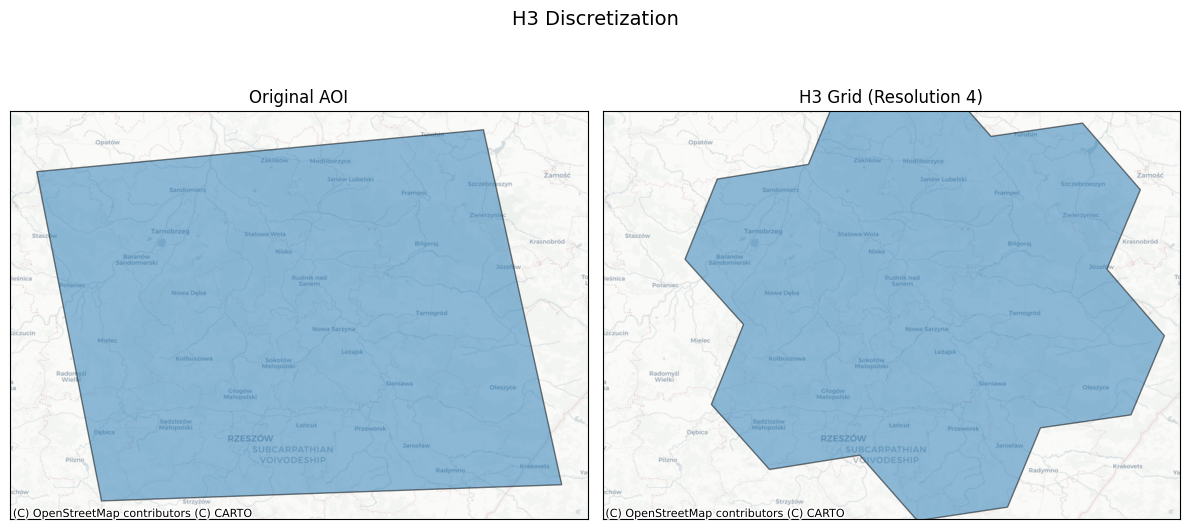

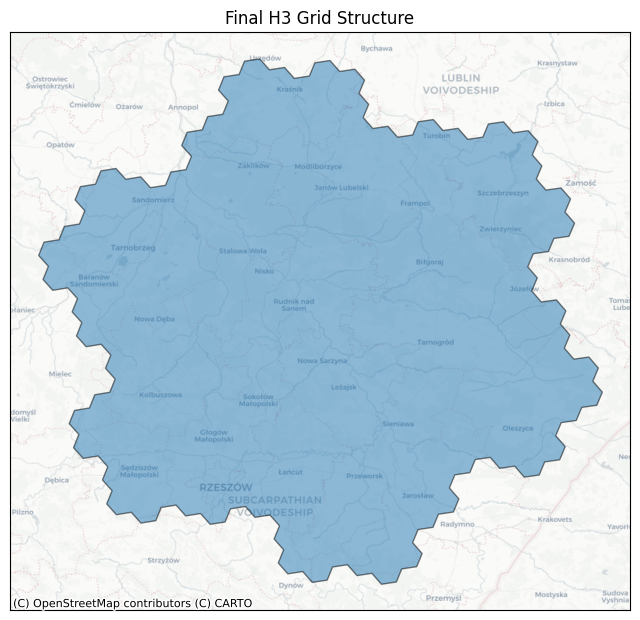

In [280]:
def plot_df(df, column=None, ax=None, title=None):
    """
    Plot a GeoPandas DataFrame with a basemap.
    
    Args:
        df: GeoDataFrame to plot.
        column: Attribute column for coloring.
        ax: Matplotlib axis object.
        title: Title string for the plot.
    """
    df = df.copy()
    # Convert to Web Mercator for compatibility with contextily basemaps
    df = df.to_crs(epsg=3857)

    if ax is None:
        _, ax = plt.subplots(figsize=(8,8))
    
    # Clean up the axes for a better map aesthetic
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    df.plot(
        ax=ax,
        alpha=0.5, 
        edgecolor='k',
        column=column, 
        categorical=True,
        legend=True, 
        legend_kwds={'loc': 'upper left'},
    )
    
    # Add a clean grayscale basemap
    cx.add_basemap(ax, crs=df.crs, source=cx.providers.CartoDB.Positron)
    
    if title:
        ax.set_title(title, fontsize=12)


def plot_shape(shape, ax=None, title="Geometry Outline"):
    """Convert a Shapely shape to a GeoDataFrame and plot it."""
    df = gpd.GeoDataFrame({'geometry': [shape]}, crs='EPSG:4326')
    plot_df(df, ax=ax, title=title)


def plot_cells(cells, ax=None, title="H3 Grid"):
    """Convert H3 indices back to a shape and plot."""
    shape = h3.cells_to_h3shape(cells)
    plot_shape(shape, ax=ax, title=title)


def plot_shape_and_cells(shape, res=9, main_title="H3 Discretization"):
    """Compare the original vector shape with the resulting H3 hexagonal grid."""
    fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
    
    # Plot 1: The original Area of Interest
    plot_shape(shape, ax=axs[0], title="Original AOI")
    
    # Plot 2: The H3 hex-grid representation
    cells = h3.h3shape_to_cells(shape, res)
    plot_cells(cells, ax=axs[1], title=f"H3 Grid (Resolution {res})")
    
    fig.suptitle(main_title, fontsize=14)
    fig.tight_layout()


def polygon_to_h3(geometry, resolution):
    """
    Convert a Shapely Polygon into a list of H3 indices at a specific resolution.
    """
    if geometry.is_empty:
        return []
    
    # H3-py expects (lat, lon) for some inputs, but geo_to_h3shape 
    # uses GeoJSON standard (lon, lat).
    coords = [[(x, y) for x, y in geometry.exterior.coords]]
    geo_json = {"type": "Polygon", "coordinates": coords}
    
    # Convert GeoJSON dict to H3 shape and fill with cells
    h3_shape = h3.geo_to_h3shape(geo_json)
    cells = h3.h3shape_to_cells(h3_shape, resolution)
    
    # Visualize the conversion process
    plot_shape_and_cells(h3_shape, res=resolution)
    
    return list(cells)

# --- Execution Logic ---

# Convert the Earth Engine AOI into a Shapely Polygon
coords = AOI_ee.getInfo()['coordinates'][0]  # Extracts [lon, lat] list
polygon_shape = Polygon(coords)

# Phase 1: Generate coarse H3 cells (Resolution 4) for high-level indexing
h3_z4_cells = polygon_to_h3(polygon_shape, 4)
print(f"Number of H3 z4 cells: {len(h3_z4_cells)}")

# Phase 2: Upsample/Refine z4 cells to z6 cells for higher granularity
h3_z6_cells = []
for cell in h3_z4_cells:
    children = h3.cell_to_children(cell, 6)
    h3_z6_cells.extend(children)

# Prepare the data for DataFrame integration
records = []
for cell in h3_z6_cells:
    lat, lon = h3.cell_to_latlng(cell)
    records.append({
        "h3": cell,
        "lat": lat,
        "lon": lon,
        "corine": None  # Placeholder for subsequent CORINE data extraction
    })

df = pd.DataFrame(records)
print(df.head())
print("Total Samples (z6):", len(df))

# Final visualization of the refined z6 grid overlaid on the z4 footprint
plot_cells(h3_z6_cells, title="Final H3 Grid Structure")

print(f"Final Count of H3 z6 cells: {len(h3_z6_cells)}")

In [281]:
def corine_2018_idx(geometry):
    raw = ee.Image("COPERNICUS/CORINE/V20/100m/2018").select("landcover").rename("corine")
    raw = raw.reproject(crs="EPSG:3035", scale=100).clip(geometry)
    idx = raw.remap(corine.codes, list(range(1, len(corine.codes) + 1))).rename("landcover_idx")
    return raw, idx

# CORINE 2018
clc_raw, clc_idx = corine_2018_idx(AOI_ee)


In [282]:
def h3_to_ee_feature(h3_index):
    """
    Converts an H3 index into a Google Earth Engine Feature.
    Handles the coordinate flip from (lat, lon) to (lon, lat).
    """
    # Get the vertices of the hexagon
    boundary_latlon = h3.cell_to_boundary(h3_index)
    
    # 🔥 COORDINATE CONVERSION: h3 uses (lat, lon), but GEE expects (lon, lat)
    boundary_lonlat = [[lon, lat] for lat, lon in boundary_latlon]
    
    geom = ee.Geometry.Polygon([boundary_lonlat])
    return ee.Feature(geom, {"h3": h3_index})

# Create a FeatureCollection from the list of H3 resolution 6 cells
hex_fc = ee.FeatureCollection(
    [h3_to_ee_feature(h) for h in h3_z6_cells]
)

# Zonal Statistics: Reduce the CORINE image regions by the hexagon collection.
# We use frequencyHistogram to count occurrences of each land-cover class per hex.
hex_corine = clc_raw.reduceRegions(
    collection=hex_fc,
    reducer=ee.Reducer.frequencyHistogram(),
    scale=100, # Scale matches CORINE 100m resolution
)

def histogram_to_fraction(f):
    # Pobierz histogram (może być pusty, jeśli hex jest poza zasięgiem danych)
    hist = ee.Dictionary(f.get("histogram"))
    
    # Warunek bezpieczeństwa: sprawdź czy histogram nie jest pusty
    return ee.Algorithms.If(
        hist.size().gt(0),
        _process_valid_hex(f, hist),
        f.set("corine_frac", {}).set("lon", 0).set("lat", 0)
    )

def _process_valid_hex(f, hist):
    total = ee.Number(hist.values().reduce(ee.Reducer.sum()))
    
    # Konwersja na frakcje
    frac = hist.map(lambda k, v: ee.Number(v).divide(total))
    
    centroid = f.geometry().centroid()
    return f.set({
        "corine_frac": frac,
        "lon": centroid.coordinates().get(0),
        "lat": centroid.coordinates().get(1)
    })

hex_corine = hex_corine.map(histogram_to_fraction)


# Transfer data from GEE servers to local Python environment
# Note: getInfo() can be slow for very large collections
features = hex_corine.getInfo()["features"]

# Parse the GEE response into a list of dictionaries for Pandas
records = []
for f in features:
    props = f["properties"]
    records.append({
        "h3": props["h3"],
        "lat": props.get("lat"),
        "lon": props.get("lon"),
        "corine_hist": props.get("histogram"), # Raw pixel counts
        "corine_frac": props.get("corine_frac")  # Percentage composition
    })

# Initialize final DataFrame for analysis
df = pd.DataFrame(records)
def get_safe_dominant(d):
    if not d or not isinstance(d, dict): return -1
    return int(max(d, key=lambda k: d[k]))

df['dominant_class_id'] = df['corine_frac'].apply(get_safe_dominant)
df = df[df['dominant_class_id'] != -1].reset_index(drop=True)
print("Data Extraction Complete. Preview:")
print(df.head())
print(sorted(list(df['dominant_class_id'].unique())))

Data Extraction Complete. Preview:
                h3        lat        lon  \
0  861e28607ffffff  50.164166  21.834289   
1  861e2860fffffff  50.145148  21.920651   
2  861e28617ffffff  50.129057  21.762905   
3  861e2861fffffff  50.110083  21.849241   
4  861e28627ffffff  50.218205  21.819314   

                                         corine_hist  \
0  {'112': 0.49411764705882355, '211': 372.701960...   
1  {'112': 283.6039215686274, '131': 147.51764705...   
2  {'112': 85.74117647058824, '122': 79.807843137...   
3  {'112': 257.3333333333333, '122': 101.23921568...   
4  {'112': 374.8352941176471, '121': 28, '211': 2...   

                                         corine_frac  dominant_class_id  
0  {'112': 0.0001417614649584785, '211': 0.106927...                313  
1  {'112': 0.08132803134411273, '131': 0.04230308...                313  
2  {'112': 0.024581786946603422, '122': 0.0228807...                313  
3  {'112': 0.07374516897218654, '122': 0.02901257...               

In [283]:
def get_dominant_color(frac_dict):
    """
    Determines a representative color for an H3 cell based on its dominant CORINE class.
    
    The function identifies which land-cover class has the highest percentage 
    within the hexagon and maps it to a standard color category.
    """
    if not frac_dict:
        # Fallback for hexagons with no underlying land-cover data
        return "gray"
    
    # Identify the class code (key) with the maximum fraction value
    dominant_class = max(frac_dict, key=lambda k: frac_dict[k])
    
    # Categorical Color Logic based on CORINE Level 1 classifications:
    # 1xx: Artificial surfaces (Urban, Industrial) -> Dark Red
    # 2xx: Agricultural areas -> Orange
    # 3xx: Forests and semi-natural areas -> Green
    # 4xx: Wetlands -> Cyan
    # 5xx: Water bodies -> Blue
    c = int(dominant_class)
    
    if c < 200: 
        return "darkred"   # Artificial surfaces
    if c < 300: 
        return "orange"    # Agricultural
    if c < 400: 
        return "green"     # Forest/Natural
    if c < 500: 
        return "cyan"      # Wetlands
    
    return "blue"          # Water bodies

# Apply the color logic to the DataFrame to create a styling column
df['dominant_color'] = df['corine_frac'].apply(get_dominant_color)

                h3        lat        lon  \
0  861e28607ffffff  50.164166  21.834289   
1  861e2860fffffff  50.145148  21.920651   
2  861e28617ffffff  50.129057  21.762905   
3  861e2861fffffff  50.110083  21.849241   
4  861e28627ffffff  50.218205  21.819314   

                                         corine_hist  \
0  {'112': 0.49411764705882355, '211': 372.701960...   
1  {'112': 283.6039215686274, '131': 147.51764705...   
2  {'112': 85.74117647058824, '122': 79.807843137...   
3  {'112': 257.3333333333333, '122': 101.23921568...   
4  {'112': 374.8352941176471, '121': 28, '211': 2...   

                                         corine_frac  dominant_class_id  \
0  {'112': 0.0001417614649584785, '211': 0.106927...                313   
1  {'112': 0.08132803134411273, '131': 0.04230308...                313   
2  {'112': 0.024581786946603422, '122': 0.0228807...                313   
3  {'112': 0.07374516897218654, '122': 0.02901257...                211   
4  {'112': 0.1076610641

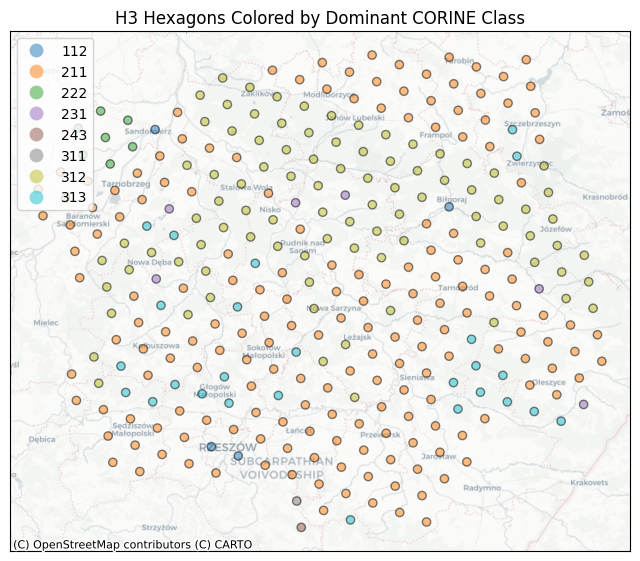

In [284]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)
print(gdf.head())
print(df.head())
print(sorted(list(gdf['dominant_class_id'].unique())))
plot_df(gdf, column='dominant_class_id', title="H3 Hexagons Colored by Dominant CORINE Class")

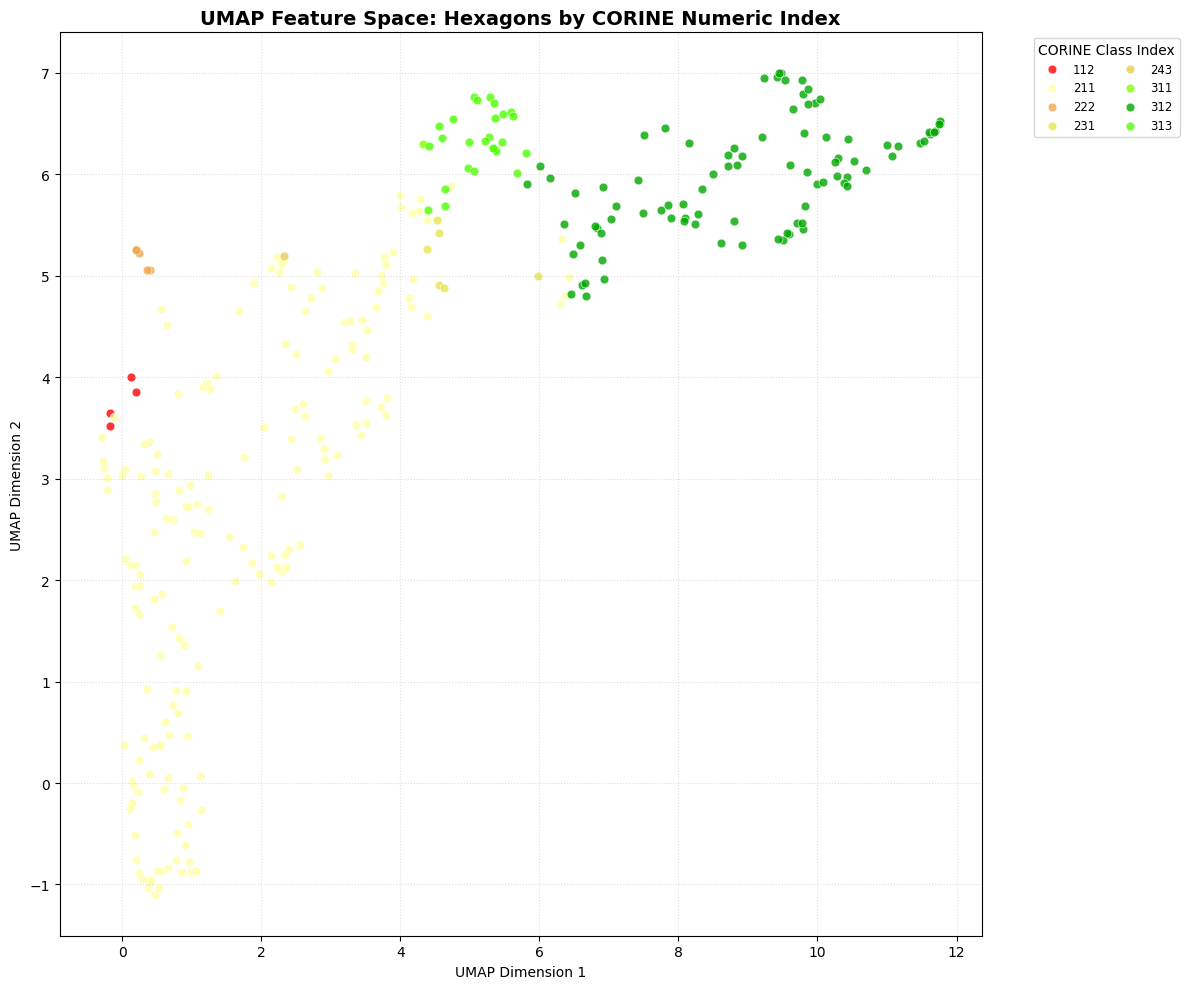

In [286]:

# Oficjalna paleta kolorów CORINE Land Cover (Level 3)
class_to_color = {
    # 1. Urban fabric (Czerwienie/Fiolety)
    111: "#E6004D", 112: "#FF0000", 121: "#CC4DF2", 122: "#CC0000",
    123: "#E6CCCC", 124: "#E6C6F2", 131: "#A600CC", 132: "#A64D00",
    133: "#E600EE", 141: "#FF4DFF", 142: "#FFA6FF",
    # 2. Agricultural areas (Żółcie/Brązy)
    211: "#FFFFA8", 212: "#FFFF00", 213: "#E6E600", 221: "#E68000",
    222: "#F2A64D", 223: "#E6A600", 231: "#E6E64D", 241: "#FFE6A6",
    242: "#FFE64D", 243: "#E6CC4D", 244: "#F2CCA6",
    # 3. Forests and semi-natural areas (Zielenie)
    311: "#80FF00", 312: "#00A600", 313: "#4DFF00", 321: "#CCF24D",
    322: "#A6FF80", 323: "#A6E64D", 324: "#A6F200", 331: "#E6E6E6",
    332: "#CCCCCC", 333: "#CCFFCC", 334: "#000000", 335: "#A6A6A6",
    # 4. Wetlands (Błękity/Fiolety)
    411: "#A6A6FF", 412: "#4D4DFF", 421: "#CCCCFF", 422: "#E6E6FF", 423: "#A6A6E6",
    # 5. Water bodies (Ciemne błękity)
    511: "#00CCF2", 512: "#00FFA6", 521: "#00A6FF", 522: "#0070FF", 523: "#004DF2"
}

# 1. Feature Matrix Construction
all_classes = sorted({
    int(k) for d in df["corine_frac"] if isinstance(d, dict) for k in d.keys()
})

X = np.zeros((len(df), len(all_classes)))
for i, d in enumerate(df["corine_frac"]):
    if not isinstance(d, dict): continue
    for j, cls in enumerate(all_classes):
        X[i, j] = d.get(str(cls), 0)

# 2. Normalization and UMAP Dimensionality Reduction
X_norm = normalize(X, norm="l1")

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
embedding = reducer.fit_transform(X_norm)

df["emb_x"] = embedding[:, 0]
df["emb_y"] = embedding[:, 1]

# 3. Preparation for Plotting
# Ensure dominant_class_id uses the raw numeric codes
df['dominant_class_id'] = df['corine_frac'].apply(
    lambda d: int(max(d, key=lambda k: d[k])) if d and isinstance(d, dict) else -1
)

unique_present_classes = sorted(df['dominant_class_id'].unique())

plt.figure(figsize=(12, 10), facecolor='white')

# 4. Scatter Plot Visualization
# We loop through unique codes to ensure each class gets its specific color and a legend entry
for cls in unique_present_classes:
    if cls <= 0: continue
    
    mask = df['dominant_class_id'] == cls
    # class_to_color maps the numeric code to the official hex palette
    color = class_to_color.get(cls, "#000000") 
    
    plt.scatter(
        df.loc[mask, "emb_x"], 
        df.loc[mask, "emb_y"], 
        c=color,
        s=40, 
        alpha=0.8,
        edgecolors='white',
        linewidth=0.5,
        label=str(cls) # Label is now strictly the numeric CORINE index
    )



# 5. Legend and Final Styling
# Using ncol=2 or 3 helps if you have many codes present
plt.legend(
    title="CORINE Class Index", 
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    fontsize='small', 
    ncol=2 
)

plt.title("UMAP Feature Space: Hexagons by CORINE Numeric Index", fontsize=14, fontweight='bold')
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

In [287]:


# 1. Color Classification Logic (Server-side GEE Logic)
def add_style_properties(f):
    """
    Applies conditional styling logic directly on the GEE server.
    Uses ee.Algorithms.If to determine colors based on the CORINE Level 1 code.
    """
    c = ee.Number(f.get("corine"))
    
    # Nested GEE conditional logic (required as standard Python 'if' doesn't run on GEE servers)
    color = ee.Algorithms.If(
        c.lt(0), "gray",                             # No Data / NaN
        ee.Algorithms.If(
            c.lt(200), "darkred",                    # Urban / Artificial surfaces
            ee.Algorithms.If(
                c.lt(300), "orange",                 # Agricultural areas
                ee.Algorithms.If(
                    c.lt(400), "green",              # Forests and semi-natural
                    ee.Algorithms.If(
                        c.lt(500), "cyan",           # Wetlands
                        "blue"                       # Water bodies
                    )
                )
            )
        )
    )
    
    # Set a 'style' dictionary compatible with ee.FeatureCollection.style() or geemap
    return f.set({
        "style": {
            "color": color,
            "pointSize": 5
        }
    })


# --- CORINE Raster Visualization Palette ---
# Standardized palette for the original CORINE 100m raster dataset
corine_vis = {
    "min": 100,
    "max": 523,
    "palette": [
        "e6004d","ff0000","cc4df2","cc0000","e6cccc",  # Artificial/Urban
        "e6cce6","a600cc","a64d00","ff4d4d","ffa6a6",
        "ffe6ff","ffffa8","ffff00","e6e600","e6ff00",
        "e6ffcc","80ff00","00a600","4dff00","ccf24d",
        "a6ff80","a6e64d","a6ffcc","4dffa6","00ccf2",
        "80f2e6","00ffa6","a6ffe6","e6f2ff","ccccff",
        "e6e6ff","a6a6ff","4d4dff","cccccc","a6a6a6"
    ]
}

import geemap

# 2. Prepare Features for GEE (passing the numerical class for styling)
ee_features = []
for _, row in df.iterrows():
    point = ee.Geometry.Point([row.lon, row.lat])
    
    # We extract the dominant class ID from the fraction dictionary
    # so the GEE server-side 'If' logic can process the numbers.
    fracs = row.corine_frac
    dom_class = int(max(fracs, key=lambda k: fracs[k])) if fracs else -1
    
    feature = ee.Feature(point, {"corine": dom_class})
    ee_features.append(feature)

# 3. Create and Style the Collection
ee_fc = ee.FeatureCollection(ee_features)
# add_style_properties is the function you defined in the previous step
styled_points = ee_fc.map(add_style_properties)

# 3. Initialize Map
m_final = geemap.Map()
m_final.centerObject(AOI_ee, 11)

# Layer 1: The Original CORINE Raster (Reference)
m_final.addLayer(clc_idx, corine.vis, "CORINE 2018")

# Layer 2: H3 Hexagon Boundaries
# We style the hex_fc to have transparent fill and black outlines
hex_outlines = hex_fc.style(color="black", fillColor="00000000", width=1)
m_final.addLayer(hex_outlines, {}, "H3 Hex Grid (z6)")

# Layer 3: Styled Classification Points
# This uses the 'style' property we set in add_style_properties
m_final.addLayer(styled_points.style(styleProperty="style"), {}, "Dominant Land Cover Points")

# Add a Legend for clarity
legend_dict = {
    'Urban/Artificial': 'darkred',
    'Agriculture': 'orange',
    'Forest/Natural': 'green',
    'Wetlands': 'cyan',
    'Water': 'blue',
    'No Data': 'gray'
}
m_final.add_legend(title="Dominant H3 Classification", legend_dict=legend_dict)

m_final

Map(center=[50.337971527239475, 22.199267281527828], controls=(WidgetControl(options=['position', 'transparent…

In [288]:


# Filter data for two classes: Urban (1xx) and Forest (3xx)
# We define them based on the dominant class calculated in the previous step
df_urban = df[df['dominant_color'] == 'darkred'].copy()
df_forest = df[df['dominant_color'] == 'green'].copy()

# Features for outlier detection (the X matrix we built earlier)
# Using only the columns corresponding to the classes present in these subsets

In [289]:
# 1. Expand the 'corine_frac' dictionary into individual columns
# json_normalize turns {'111': 0.5, '211': 0.5} into separate columns for each class.
# We fill NaN with 0 because a missing class in a hexagon means it has 0% coverage.
fractions_df = pd.json_normalize(df['corine_frac']).fillna(0)

# 2. Ensure all column names are strings
# This maintains consistency, especially when dealing with numeric CORINE codes as headers.
fractions_df.columns = [str(col) for col in fractions_df.columns]

# 3. Concatenate the new fraction columns with the main DataFrame
# We reset the index to ensure the rows align perfectly during the side-by-side join.
df = pd.concat([df.reset_index(drop=True), fractions_df], axis=1)

# 4. Filter and verify the feature columns
# Create a list of column names that exist in the DataFrame and correspond 
# to our known CORINE classes. These will be used as input for our models.
feature_cols = [str(c) for c in all_classes if str(c) in df.columns]

# Display the first few rows of the flattened feature matrix
print(f"Total features (CORINE classes) identified: {len(feature_cols)}")
print(df[feature_cols].head())

Total features (CORINE classes) identified: 25
        112       121       122  124       131  132  133  141  142       211  \
0  0.000142  0.000000  0.000000  0.0  0.000000  0.0  0.0  0.0  0.0  0.106928   
1  0.081328  0.000000  0.000000  0.0  0.042303  0.0  0.0  0.0  0.0  0.236609   
2  0.024582  0.000000  0.022881  0.0  0.000000  0.0  0.0  0.0  0.0  0.180378   
3  0.073745  0.000000  0.029013  0.0  0.000000  0.0  0.0  0.0  0.0  0.333093   
4  0.107661  0.008042  0.000000  0.0  0.000000  0.0  0.0  0.0  0.0  0.647771   

   ...       312       313  321       324  331  333  411  412  511       512  
0  ...  0.264619  0.399296  0.0  0.010889  0.0  0.0  0.0  0.0  0.0  0.027542  
1  ...  0.070648  0.240239  0.0  0.021221  0.0  0.0  0.0  0.0  0.0  0.000000  
2  ...  0.189631  0.296373  0.0  0.041836  0.0  0.0  0.0  0.0  0.0  0.029530  
3  ...  0.102478  0.147823  0.0  0.000000  0.0  0.0  0.0  0.0  0.0  0.000000  
4  ...  0.013499  0.044385  0.0  0.025956  0.0  0.0  0.0  0.0  0.0  0.000000 

In [290]:
from scipy import stats
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

def apply_outlier_methods(sub_df, features):
    """
    Apply multiple anomaly detection techniques to a subset of H3 cells.
    
    This function compares each hexagon against the 'norm' of its group 
    (e.g., comparing one urban cell against all other urban cells).
    """
    if sub_df.empty:
        return sub_df
    
    # Extract the feature matrix for the specific subset
    X_sub = sub_df[features].values
    
    # 1. Z-Score Analysis (Univariate Outlier Detection)
    # Identifies cells where at least one land-cover percentage is 
    # more than 3 standard deviations from the mean.
    z_scores = np.abs(stats.zscore(X_sub, axis=0))
    # Handle features with zero variance (e.g., if no cells have a specific class)
    z_scores = np.nan_to_num(z_scores)
    # Mark as outlier if ANY feature exceeds the threshold
    sub_df['outlier_zscore'] = (z_scores > 3).any(axis=1)
    
    # 2. Local Outlier Factor (LOF) (Density-Based Detection)
    # Measures the local density deviation of a cell compared to its neighbors.
    # It detects cells that are 'isolated' in the feature space.
    lof = LocalOutlierFactor(n_neighbors=min(20, len(sub_df)-1), contamination=0.05)
    sub_df['outlier_lof'] = lof.fit_predict(X_sub) == -1
    
    # 3. Isolation Forest (Tree-Based Anomaly Detection)
    # Isolates observations by randomly selecting a feature and a split value.
    # Anomalies are easier to isolate and thus have shorter paths in the trees.
    iso = IsolationForest(contamination=0.05, random_state=42)
    sub_df['outlier_iso'] = iso.fit_predict(X_sub) == -1
    
    return sub_df

# --- Execution for specific Land Cover strata ---

# Separate the data into strata to find outliers relative to their own type
# (e.g., an 'outlier' forest is more interesting than comparing a forest to a city)
df_urban = df[df['dominant_color'] == 'darkred'].copy()
df_forest = df[df['dominant_color'] == 'green'].copy()

# Apply the outlier detection pipeline
df_urban = apply_outlier_methods(df_urban, feature_cols)
df_forest = apply_outlier_methods(df_forest, feature_cols)

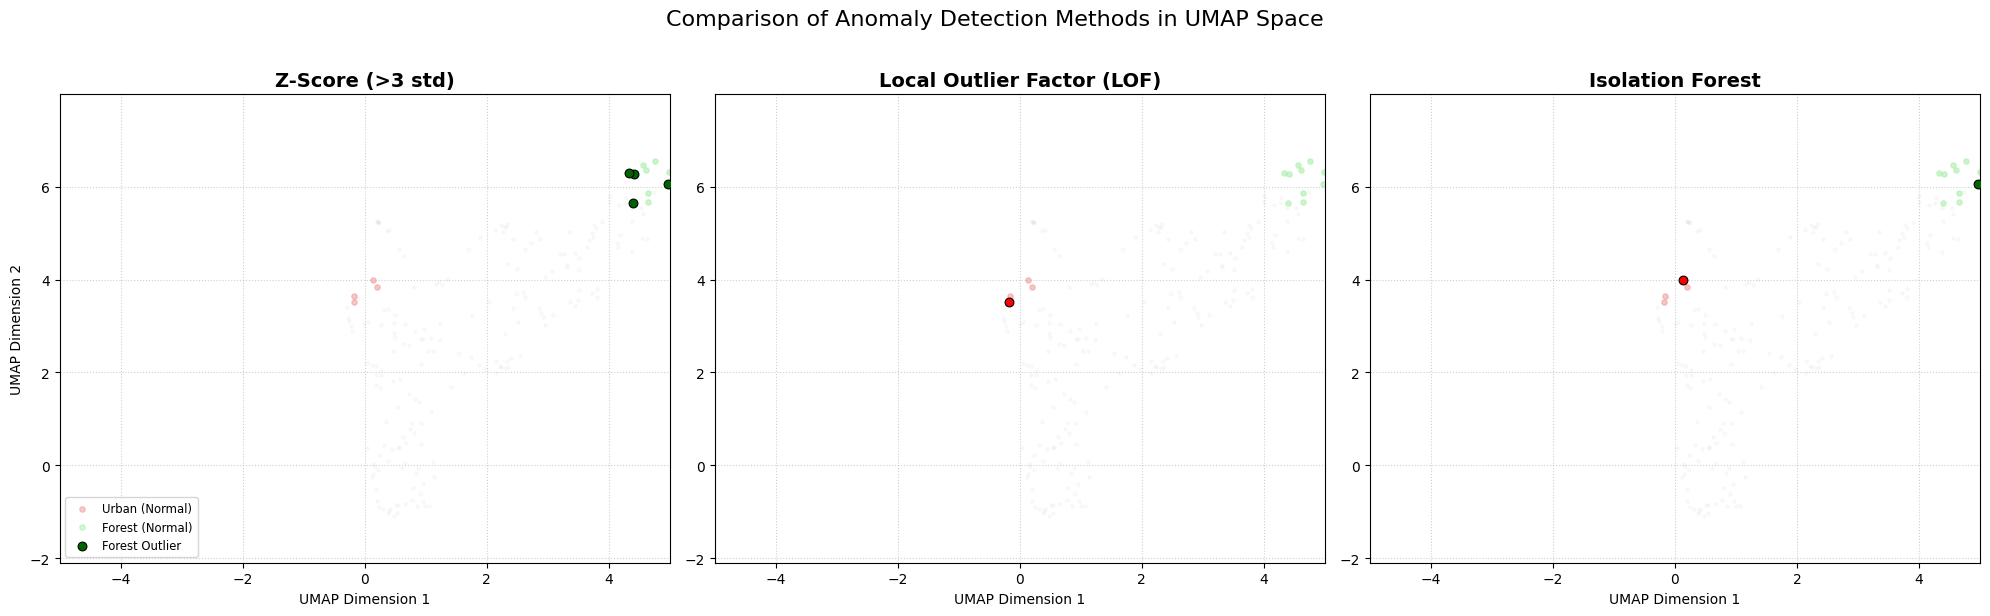

In [291]:
# 1. Define detection methods and descriptive titles
# We are comparing three distinct mathematical approaches to identifying "unusual" hexagons.
methods = ['outlier_zscore', 'outlier_lof', 'outlier_iso']
titles = ['Z-Score (>3 std)', 'Local Outlier Factor (LOF)', 'Isolation Forest']

# Create a side-by-side comparison to evaluate model agreement
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor='white')

for i, method in enumerate(methods):
    ax = axes[i]
    
    # Background Context: Plot all data points as faint grey dots.
    # This helps visualize the "manifold" or shape of the entire dataset.
    ax.scatter(df["emb_x"], df["emb_y"], c='lightgrey', alpha=0.1, s=5, zorder=1)
    
    # --- URBAN STRATA ANALYSIS ---
    if method in df_urban.columns:
        # Normal Urban points (Typical city/industrial landscapes)
        norm_urb = df_urban[~df_urban[method]]
        ax.scatter(norm_urb["emb_x"], norm_urb["emb_y"], c='lightcoral', alpha=0.4, s=15, label='Urban (Normal)')
        
        # Urban Outliers (Atypical city layouts or unusual land-cover mixes)
        out_urb = df_urban[df_urban[method]]
        if not out_urb.empty:
            ax.scatter(out_urb["emb_x"], out_urb["emb_y"], c='red', s=40, 
                       edgecolors='black', linewidth=0.8, zorder=5, label='Urban Outlier')
    
    # --- FOREST STRATA ANALYSIS ---
    if method in df_forest.columns:
        # Normal Forest points (Typical natural/semi-natural areas)
        norm_for = df_forest[~df_forest[method]]
        ax.scatter(norm_for["emb_x"], norm_for["emb_y"], c='lightgreen', alpha=0.4, s=15, label='Forest (Normal)')
        
        # Forest Outliers (e.g., forests with unusual road density or water bodies)
        out_for = df_forest[df_forest[method]]
        if not out_for.empty:
            ax.scatter(out_for["emb_x"], out_for["emb_y"], c='darkgreen', s=40, 
                       edgecolors='black', linewidth=0.8, zorder=5, label='Forest Outlier')

    # Formatting and Styling
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.set_xlabel("UMAP Dimension 1")
    ax.set_xlim(-5, 5)
    ax.set_ylim(df["emb_y"].min()-1, df["emb_y"].max()+1)
    
    # Only show Y-axis label and Legend on the first plot to reduce clutter
    if i == 0:
        ax.set_ylabel("UMAP Dimension 2")
        ax.legend(loc='lower left', fontsize='small', frameon=True)
        
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle("Comparison of Anomaly Detection Methods in UMAP Space", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [292]:
from sklearn.ensemble import IsolationForest

def detect_outliers_all_classes(df, features, contamination=0.05):
    """
    Perform global anomaly detection across all H3 cells using Isolation Forest.
    
    Args:
        df: The flattened DataFrame containing land-cover fractions.
        features: List of string column names representing CORINE classes.
        contamination: The expected proportion of outliers in the dataset.
    """
    # Create a copy to ensure the original DataFrame remains unchanged
    df_result = df.copy()
    
    # Initialize the Isolation Forest model
    # n_estimators=100: Number of trees in the forest.
    # contamination=0.05: Flags approximately 5% of the data as anomalies.
    iso_forest = IsolationForest(
        n_estimators=100, 
        contamination=contamination, 
        random_state=42
    )
    
    # Prepare the feature matrix (fraction values for all classes)
    X = df_result[features].values
    
    # Prediction: Returns 1 for normal observations and -1 for outliers
    preds = iso_forest.fit_predict(X)
    
    # Binary flag: True if the cell is an anomaly
    df_result['is_outlier'] = (preds == -1)
    
    # Outlier Score: The anomaly score of the input samples.
    # Lower (more negative) values indicate a higher degree of abnormality.
    # A score of 0 typically acts as the decision threshold.
    df_result['outlier_score'] = iso_forest.decision_function(X)
    
    return df_result

# --- Execution ---

# Run detection using the previously prepared 'feature_cols'
df_final = detect_outliers_all_classes(df, feature_cols)



print(f"Global analysis complete.")
print(f"Total outliers detected across all classes: {df_final['is_outlier'].sum()}")

# Quick look at the most 'extreme' outliers (lowest scores)
print("\nTop 5 most anomalous H3 cells:")
print(df_final.nsmallest(5, 'outlier_score')[['h3', 'outlier_score', 'dominant_color']])

Global analysis complete.
Total outliers detected across all classes: 16

Top 5 most anomalous H3 cells:
                  h3  outlier_score dominant_color
289  861e280e7ffffff      -0.166881          green
285  861e280c7ffffff      -0.146647          green
270  861e28037ffffff      -0.104965         orange
276  861e2806fffffff      -0.103915          green
25   861e286e7ffffff      -0.090651         orange


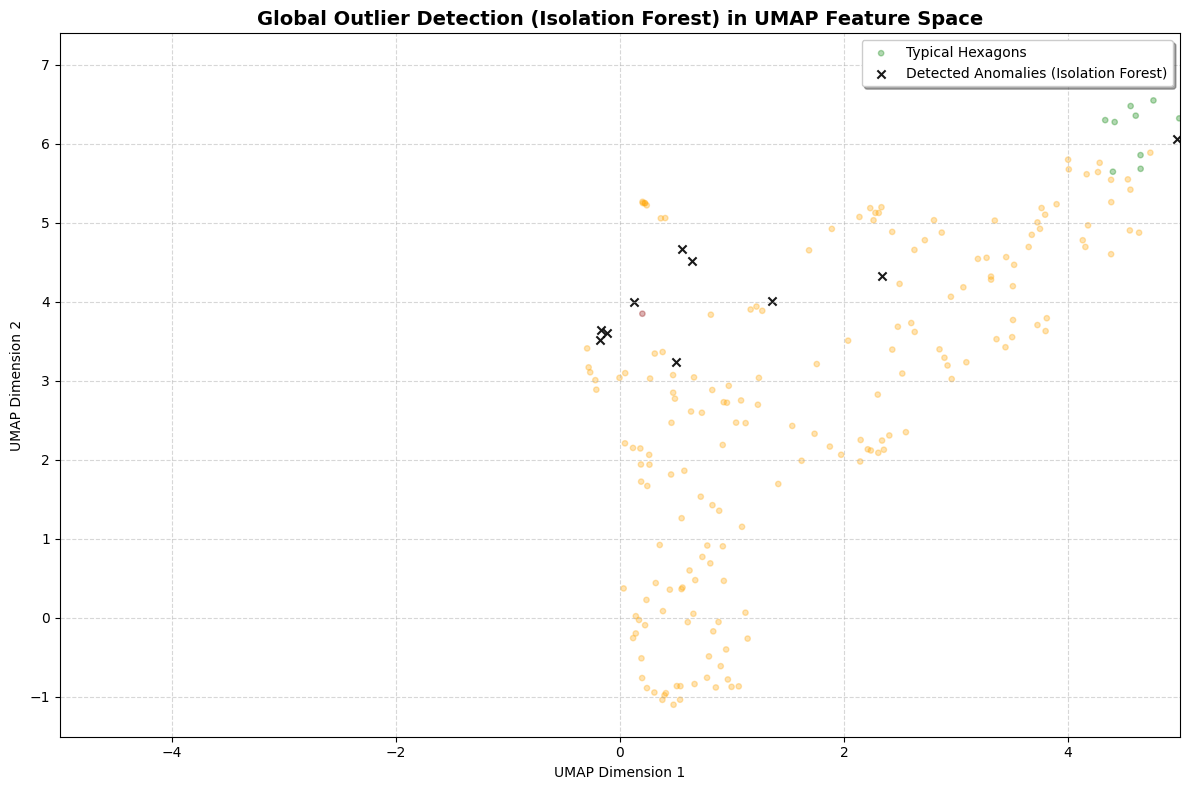

In [293]:
plt.figure(figsize=(12, 8), facecolor='white')

# 1. Plot normal observations (Background)
# We use the original dominant colors but with low alpha (transparency) 
# to keep the focus on the anomalies.
normal_points = df_final[~df_final['is_outlier']]
plt.scatter(
    normal_points["emb_x"], 
    normal_points["emb_y"], 
    c=normal_points['dominant_color'], 
    s=15, 
    alpha=0.3, 
    label='Typical Hexagons'
)

# 2. Plot global outliers (Foreground)
# We use a distinct marker ('x') and a high-contrast color (black)
# to highlight the cells that Isolation Forest identified as anomalous.
outliers = df_final[df_final['is_outlier']]
plt.scatter(
    outliers["emb_x"], 
    outliers["emb_y"], 
    c='black', 
    s=35, 
    marker='x', 
    alpha=0.9, 
    linewidths=1.5,
    label='Detected Anomalies (Isolation Forest)'
)



# 3. Chart Decoration
plt.title("Global Outlier Detection (Isolation Forest) in UMAP Feature Space", fontsize=14, fontweight='bold')
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(loc='best', frameon=True, shadow=True)
plt.xlim(-5, 5)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## Machine Learning for Space Applications
# Lab 3: LULC Classification

Lab 3 was added to notebook form lab2 because we are working on outputs from previous classes.

1.   Google Satellite Embeddings
2.   CORINE 2018


# Objectives:

1. Use distilled dataset from Lab 2 to train CORINE classifier on the target Area-of-Interest using three different classification methods
2. Predict CORINE classes on the target Area-of-Interest
3. Construct Confusion matrices for the three classification methods
4. Select the best classification method and construct CORINE classification raster map of the target Area-of-Interest

Authors: 
Martyna Durda, Katarzyna Wcisło

Gemini 3 was used to add comments

In [300]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import numpy as np

# 1. Create a clean dataset by filtering rows with a valid CORINE ID
df_clean = df[df['dominant_class_id'] > 0].copy()

# --- FIX: Filter out classes that have only 1 member to allow stratification ---
# Count occurrences of each class
class_counts = df_clean['dominant_class_id'].value_counts()
# Keep only classes with at least 2 samples
valid_classes = class_counts[class_counts >= 2].index
df_clean = df_clean[df_clean['dominant_class_id'].isin(valid_classes)].copy()

# 2. Prepare target vector y and initialize feature matrix X
y = df_clean['dominant_class_id'].values

# 1. Prepare unique class list and map them to indices
all_classes = sorted(df_clean['dominant_class_id'].unique())
class_to_idx = {cls: i for i, cls in enumerate(all_classes)}

# 2. Re-initialize feature matrix based on the identified unique classes
X_features = np.zeros((len(df_clean), len(all_classes)))

# 3. Populate the feature matrix with class distribution data
# Using reset_index() to ensure i matches the matrix row index correctly
for i, (idx, row) in enumerate(df_clean.iterrows()):
    # Get the dictionary of class fractions for the current hexagon
    distribution = row.get('class_fractions', {}) 
    
    for cls_id, fraction in distribution.items():
        if cls_id in class_to_idx:
            col_idx = class_to_idx[cls_id]
            # Fill matrix with the fraction value at the correct index
            X_features[i, col_idx] = fraction

# Print the final shape of the constructed feature matrix
print(f"Feature matrix shape: {X_features.shape}")

# --- REFINED SPLITTING STRATEGY ---

# 1. Initial split: 70% for (training + validation) and 30% for final testing
# Stratification ensures that rare classes are represented in both sets
X_temp, X_test, y_temp, y_test = train_test_split(
    X_features, y, test_size=0.30, random_state=42, stratify=y
)

# 2. Second split: Partition the 70% block into Training and Validation sets
# A test_size of 0.285 here allocates roughly 20% of the total data to validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.285, random_state=42, stratify=y_temp
)

# Output the sample counts for each dataset split
print(f"Data Split Summary:")
print(f"Train:      {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test:       {X_test.shape[0]} samples")

Feature matrix shape: (311, 6)
Data Split Summary:
Train:      155 samples
Validation: 62 samples
Test:       94 samples


In [301]:

# Updated models dictionary
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
# Updated models dictionary
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Dictionary to store performance on all sets
performance_metrics = {}

for name, clf in models.items():
    # Fit on training data
    clf.fit(X_train, y_train)
    
    # Predict on all three sets
    y_train_pred = clf.predict(X_train)
    y_val_pred = clf.predict(X_val)
    y_test_pred = clf.predict(X_test)
    
    performance_metrics[name] = {
        "train_acc": accuracy_score(y_train, y_train_pred),
        "val_acc": accuracy_score(y_val, y_val_pred),
        "test_acc": accuracy_score(y_test, y_test_pred),
        "model": clf,
        "y_test_pred": y_test_pred
    }
    
    print(f"\nModel: {name}")
    print(f"Train Acc: {performance_metrics[name]['train_acc']:.3f} | "
          f"Val Acc: {performance_metrics[name]['val_acc']:.3f} | "
          f"Test Acc: {performance_metrics[name]['test_acc']:.3f}")


Model: Random Forest
Train Acc: 0.568 | Val Acc: 0.581 | Test Acc: 0.574

Model: SVM (RBF)
Train Acc: 0.568 | Val Acc: 0.581 | Test Acc: 0.574

Model: KNN
Train Acc: 0.568 | Val Acc: 0.581 | Test Acc: 0.574


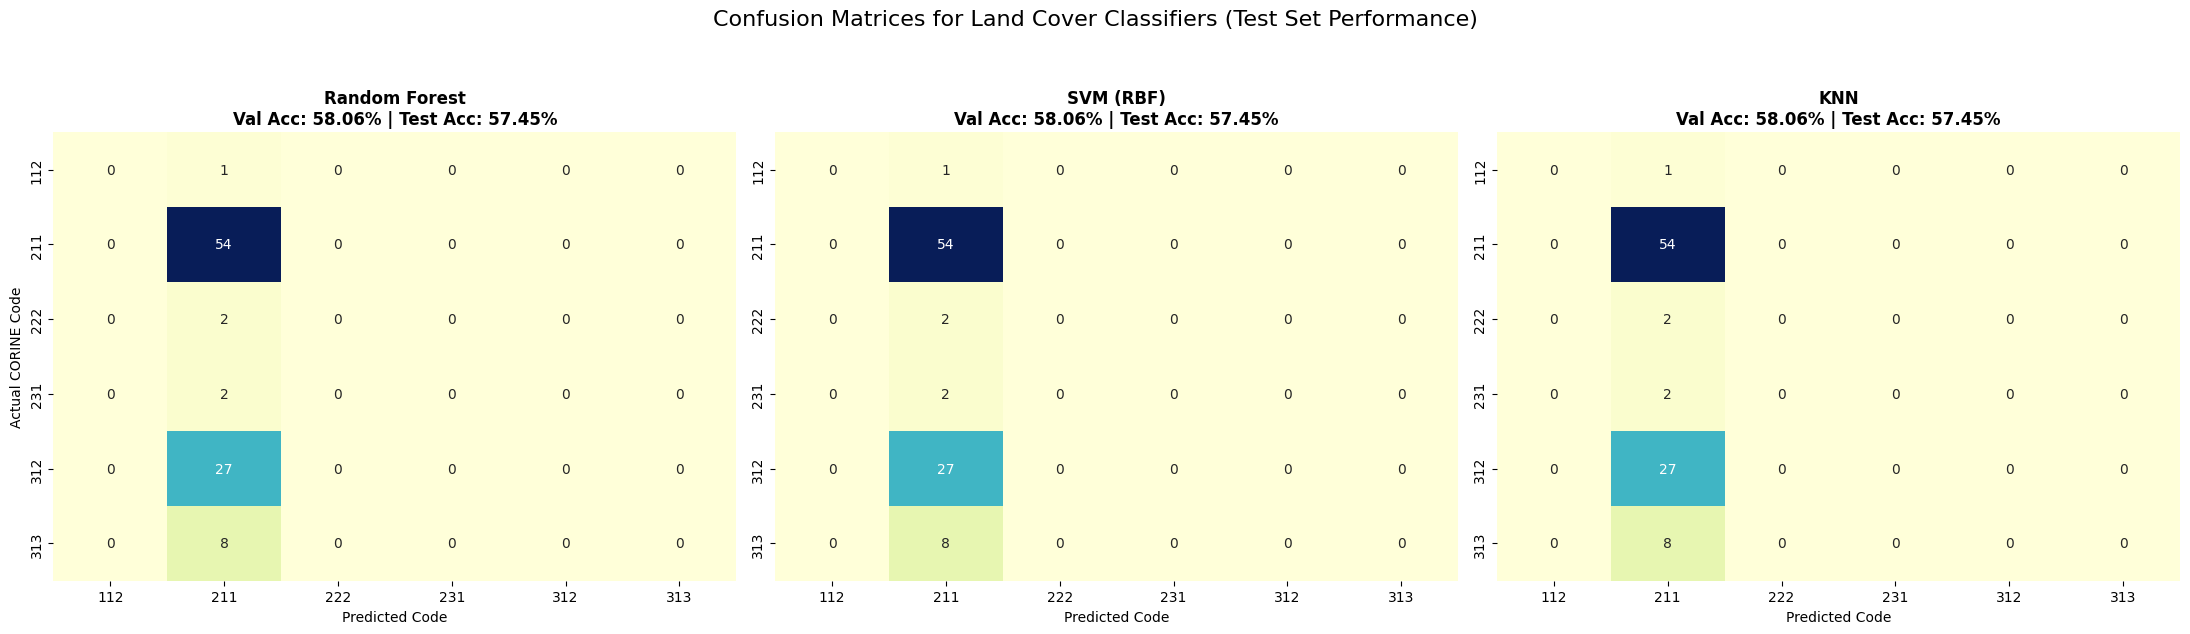

In [302]:
# Model Definitions
# Initializing three different classification algorithms for comparison
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', C=1.0),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Plot Setup
# Creating a side-by-side layout for three confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(22, 6), facecolor='white')

# Identifying unique class labels in the target variable for axis mapping
unique_labels = np.unique(y)
str_labels = [str(l) for l in unique_labels]

# Iterate through each model to train and evaluate
for i, (name, clf) in enumerate(models.items()):
    # Training phase: Fitting the model using the training subset
    clf.fit(X_train, y_train)
    
    # Validation phase: Checking performance on unseen validation data to tune/monitor
    val_acc = accuracy_score(y_val, clf.predict(X_val))
    
    # Testing phase: Final evaluation on the hold-out test set
    y_pred = clf.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    
    # Generate Confusion Matrix
    # This matrix compares the actual ground truth vs. the model's predictions
    cm = confusion_matrix(y_test, y_pred, labels=unique_labels)
    
    # Heatmap Visualization
    # annot=True shows the counts, fmt='d' ensures integer formatting
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[i], cbar=False,
                xticklabels=str_labels, yticklabels=str_labels)
    
    # Labeling each subplot with model name and accuracy metrics
    axes[i].set_title(f"{name}\nVal Acc: {val_acc:.2%} | Test Acc: {test_acc:.2%}", 
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Predicted Code")
    
    # Only show the Y-axis label on the first plot to avoid clutter
    if i == 0:
        axes[i].set_ylabel("Actual CORINE Code")

# Final Figure Styling
plt.suptitle("Confusion Matrices for Land Cover Classifiers (Test Set Performance)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

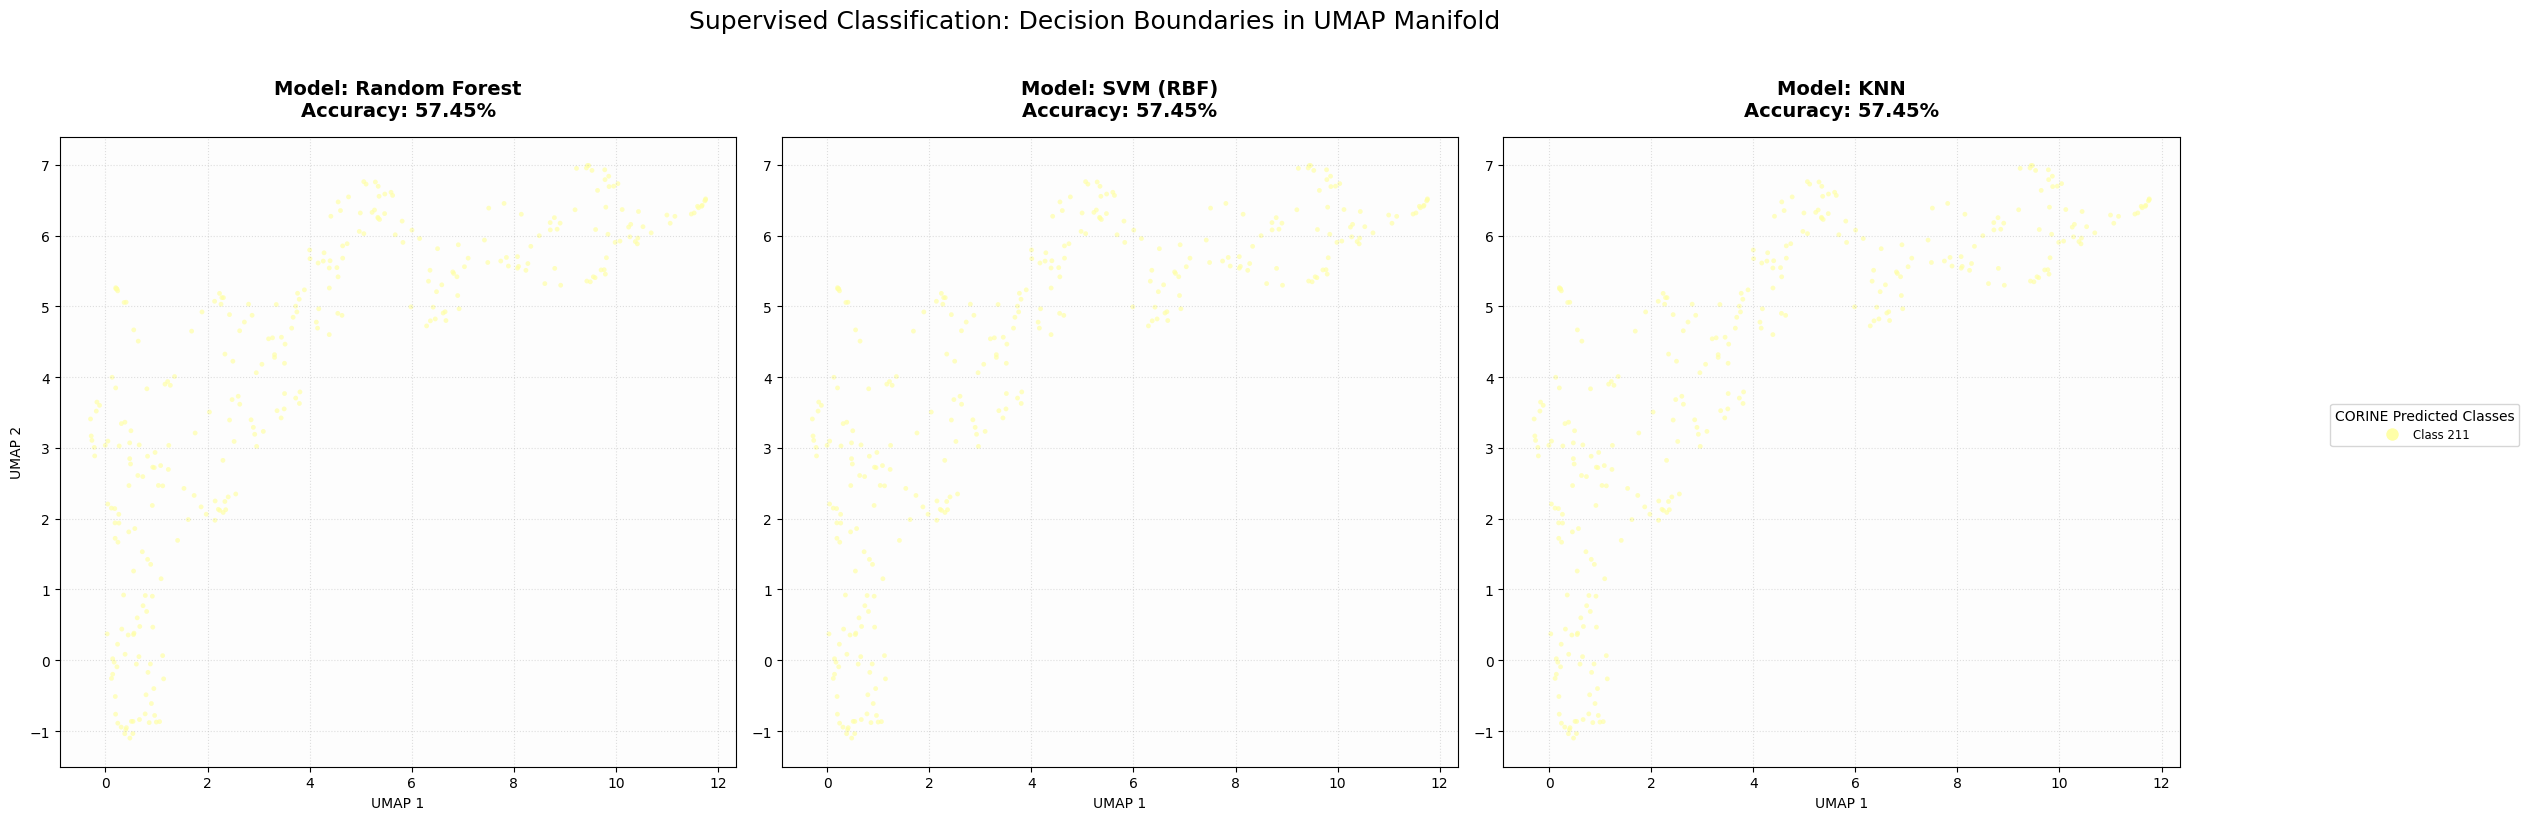

In [303]:
import numpy as np 
from matplotlib.lines import Line2D

# 1. Generating predictions for all trained models
# We store predictions from each model in a dictionary for easy comparison
all_preds = {}
for name, res in performance_metrics.items():
    all_preds[name] = res['model'].predict(X_features)

# 2. Creating a comparative visualization plot
# 1 row, 3 columns - one for each model's decision outcome
fig, axes = plt.subplots(1, 3, figsize=(22, 8), facecolor='white')

# Dictionary to store legend data globally to avoid duplicate entries
global_legend_info = {}

for i, (name, preds) in enumerate(all_preds.items()):
    ax = axes[i]
    ax.set_facecolor('#fdfdfd')
    
    # Identify which classes were predicted by this specific model
    unique_preds = np.unique(preds)
    for cls in unique_preds:
        # Create a boolean mask to locate rows predicted as this class
        mask = (preds == cls)
        # Fetch the official CORINE hex color for this class index
        color = class_to_color.get(int(cls), "#000000")
        
        # Plot predicted classes on the UMAP 2D projection
        ax.scatter(
            df_clean.loc[mask, "emb_x"], 
            df_clean.loc[mask, "emb_y"], 
            c=color,
            s=12, 
            alpha=0.7,
            edgecolors='none'
        )
        
        # Collect color info for the final unified legend
        if cls not in global_legend_info:
            global_legend_info[cls] = color

    # Retrieve and display the test accuracy from performance_metrics
    acc = performance_metrics[name]['test_acc']
    ax.set_title(f"Model: {name}\nAccuracy: {acc:.2%}", 
                 fontsize=14, fontweight='bold', pad=15)
    
    ax.set_xlabel("UMAP 1")
    if i == 0:
        ax.set_ylabel("UMAP 2")
    ax.grid(True, linestyle=':', alpha=0.4)

# 3. Constructing a sorted, unified legend for all plots
# Sorting by class ID ensures a clean and logical legend order
sorted_keys = sorted(global_legend_info.keys())
handles = [Line2D([0], [0], marker='o', color='w', 
                  markerfacecolor=global_legend_info[k], markersize=10) for k in sorted_keys]
labels = [f"Class {int(k)}" for k in sorted_keys]

# Placing the legend outside the main plot area to prevent overlap
fig.legend(handles, labels, title="CORINE Predicted Classes", 
           loc='center right', bbox_to_anchor=(1.15, 0.5), ncol=2, fontsize='small')

# Final formatting and display
plt.suptitle("Supervised Classification: Decision Boundaries in UMAP Manifold", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Automatic Selection of the Best Model
best_model_name = max(performance_metrics, key=lambda k: performance_metrics[k]['test_acc'])
best_clf = performance_metrics[best_model_name]['model']
print('Random Forest Test Accuracy:')
print(performance_metrics['Random Forest']['test_acc'])

print('SVM Test Accuracy:')
print(performance_metrics['SVM (RBF)']['test_acc'])

print('KNN Test Accuracy:')
print(performance_metrics['KNN']['test_acc'])

print(f"Selected Model: {best_model_name}")

# 2. Predict classes for the entire dataset (including Train/Val/Test)
# This ensures we have a complete coverage for the map
full_predictions = best_clf.predict(X_features)
df_clean['predicted_class'] = full_predictions

Random Forest Test Accuracy:
0.6234567901234568
SVM Test Accuracy:
0.6234567901234568
KNN Test Accuracy:
0.6234567901234568
Selected Model: Random Forest


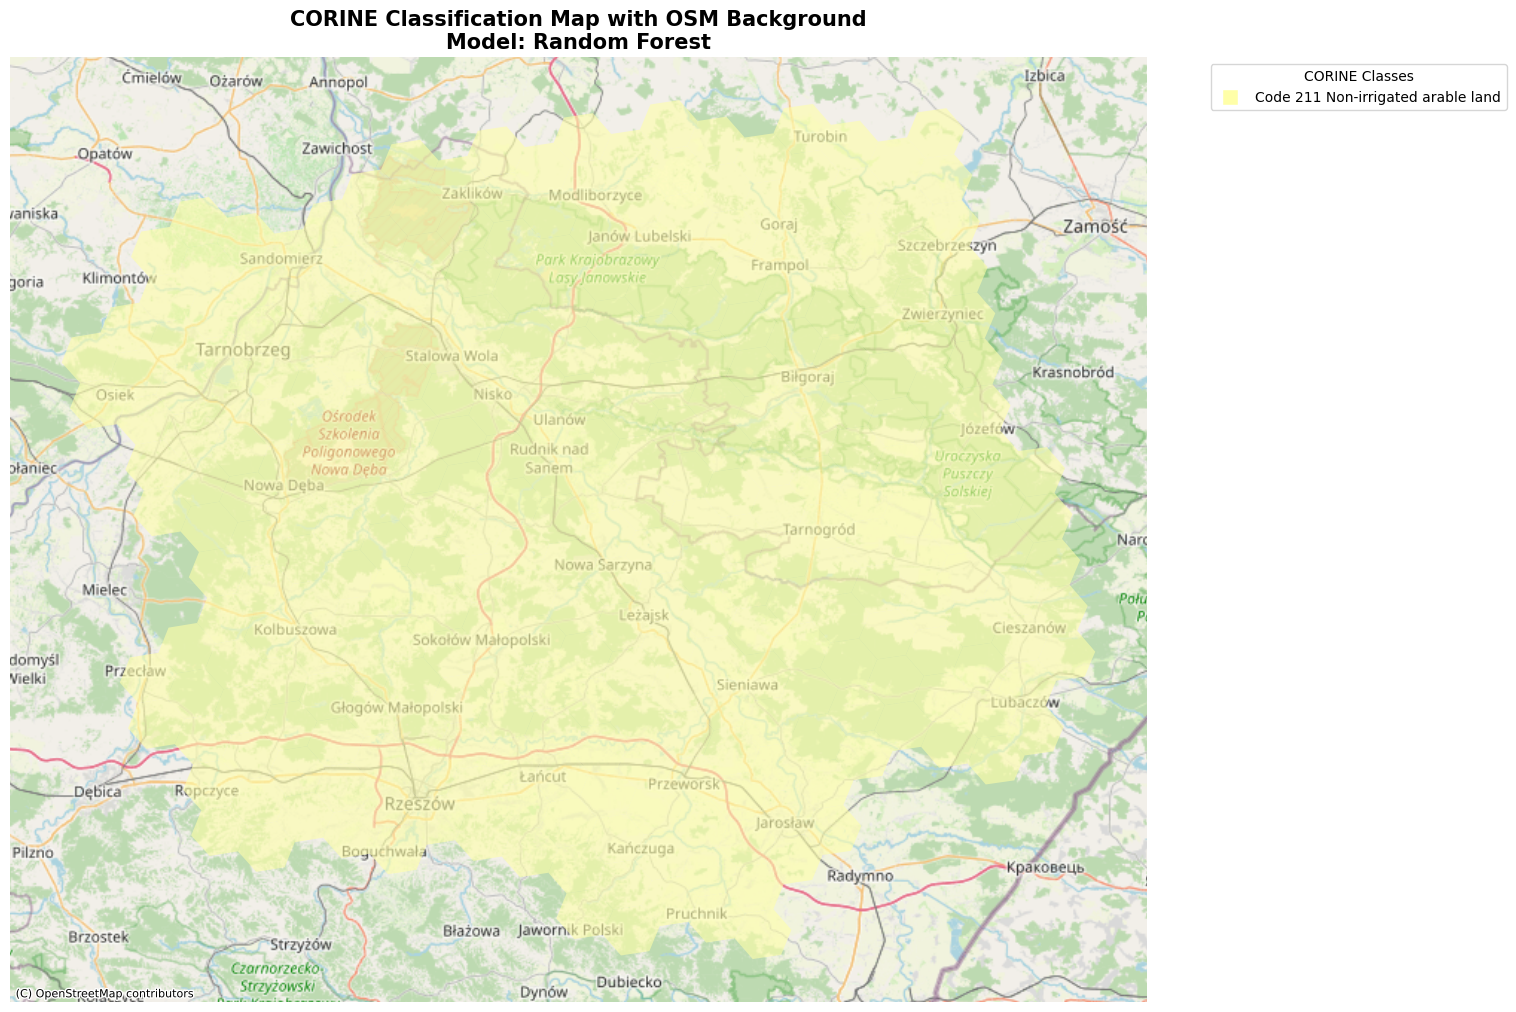

In [307]:
import h3
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from shapely.geometry import Polygon
import contextily as ctx

# Dictionary mapping CORINE codes to Polish names for clear labeling
clc_names = {
    111: "Continuous urban fabric",
    112: "Discontinuous urban fabric",
    121: "Industrial or commercial units",
    122: "Road and rail networks and associated land",
    131: "Mineral extraction sites",
    133: "Construction sites",
    141: "Green urban areas",
    142: "Sport and leisure facilities",
    211: "Non-irrigated arable land",
    231: "Pastures",
    242: "Complex cultivation patterns",
    243: "Land principally occupied by agriculture, with significant areas of natural vegetation",
    311: "Broad-leaved forest",
    312: "Coniferous forest",
    313: "Mixed forest",
    321: "Natural grasslands",
    324: "Transitional woodland-shrub",
    411: "Inland marshes",
    511: "Water courses",
    512: "Water bodies"
}

# --- GEOMETRY CONVERSION FUNCTION ---
def h3_to_polygon(h3_id):
    """Converts an H3 index into a Shapely Polygon for mapping."""
    h3_str = str(h3_id)
    try:
        # Compatibility for h3-py 4.x
        boundary = h3.cell_to_boundary(h3_str)
        return Polygon([(lng, lat) for lat, lng in boundary])
    except AttributeError:
        # Compatibility for h3-py 3.x
        boundary = h3.h3_to_geo_boundary(h3_str)
        return Polygon([(lng, lat) for lat, lng in boundary])

# --- DATA PREPARATION ---
# Generating spatial polygons from H3 hex IDs
df_clean['geometry'] = df_clean['h3'].apply(h3_to_polygon)
gdf_map = gpd.GeoDataFrame(df_clean, geometry='geometry', crs="EPSG:4326")

# CRITICAL STEP: Projecting to Web Mercator (EPSG:3857) 
# Required for compatibility with contextily basemaps
gdf_map = gdf_map.to_crs(epsg=3857)

# --- MODEL SELECTION & PREDICTION ---
# Automatically selecting the model with the highest test accuracy
best_model_name = max(performance_metrics, key=lambda k: performance_metrics[k]['test_acc'])
best_clf = performance_metrics[best_model_name]['model']
# Running the prediction on the feature set
gdf_map['predicted_class'] = best_clf.predict(X_features)

# --- VISUALIZATION ---
fig, ax = plt.subplots(1, 1, figsize=(15, 12), facecolor='white')

unique_preds = sorted(gdf_map['predicted_class'].unique())
legend_elements = []

# Iterating through predicted classes to plot each group with its specific color
for cls in unique_preds:
    cls_int = int(cls)
    mask = gdf_map['predicted_class'] == cls
    color = class_to_color.get(cls_int, "#000000")
    
    # Plotting hexagons with alpha=0.6 so the OSM basemap remains visible underneath
    gdf_map[mask].plot(ax=ax, color=color, edgecolor='none', alpha=0.6)
    
    # Constructing legend entries using the CORINE nomenclature
    name = clc_names.get(cls_int, "")
    label_text = f"Code {cls_int} {name}"
    legend_elements.append(Line2D([0], [0], marker='s', color='w', 
                                  label=label_text, 
                                  markerfacecolor=color, markersize=12))

# --- ADDING BACKGROUND BASEMAP (OSM) ---
# Fetching and rendering OpenStreetMap tiles
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# --- FINAL STYLING ---
plt.title(f"CORINE Classification Map with OSM Background\nModel: {best_model_name}", 
          fontsize=15, fontweight='bold')
ax.legend(handles=legend_elements, title="CORINE Classes", 
          bbox_to_anchor=(1.05, 1), loc='upper left')

# Disabling axis coordinates for a cleaner aesthetic
ax.set_axis_off()
plt.tight_layout()
plt.show()